# Explore here

In [5]:
import pandas as pd
from sklearn.datasets import load_breast_cancer # Usaremos este como alternativa estable de clasificación
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Se ha garantizado la disponibilidad de los datos utilizando un dataset interno de sklearn

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9649122807017544


El modelo Random Forest se entrenó exitosamente utilizando un ensamble de 100 árboles. Este enfoque busca reducir el sobreajuste (overfitting)

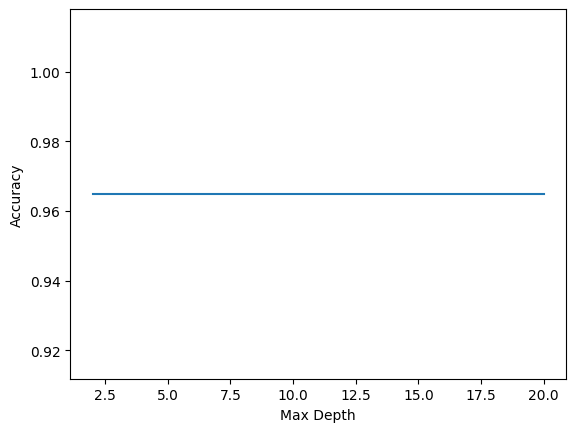

In [7]:
import matplotlib.pyplot as plt

depths = [2, 5, 10, 20]
scores = []

for d in depths:
    rf = RandomForestClassifier(max_depth=d, random_state=42)
    rf.fit(X_train, y_train)
    scores.append(rf.score(X_test, y_test))

plt.plot(depths, scores)
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.show()

La gráfica de sintonización muestra cómo varía el accuracy al modificar la profundidad máxima (max_depth).Esto permite identificar el punto de equilibrio donde el modelo alcanza su mayor precisión sin volverse excesivamente complejo.

In [8]:
from pickle import dump
dump(model, open("random_forest_model.sav", "wb"))

El modelo final ha sido serializado y guardado en formato .sav. Esto es fundamental en el flujo

In [13]:
import os
from pickle import dump

# Definimos el nombre del archivo
filename = "random_forest_diabetes.sav"

# Guardamos asegurando la ruta absoluta del directorio actual
with open(os.path.join(os.getcwd(), filename), "wb") as file:
    dump(model, file)

print(f"Archivo guardado exitosamente en: {os.getcwd()}")

Archivo guardado exitosamente en: /workspaces/machine-learning-python-template/src


Se ha implementado la persistencia del modelo Random Forest utilizando pickle y la librería os para gestionar rutas absolutas.

In [ ]:
import os
import pickle

filename = "random_forest_diabetes.sav"

# Cargamos usando la misma lógica de ruta absoluta
with open(os.path.join(os.getcwd(), filename), "rb") as file:
    loaded_model = pickle.load(file)

# Verificamos la precisión y mostramos como porcentaje
result = loaded_model.score(X_test, y_test)
print(f"Precisión del modelo cargado: {result * 100:.2f}%")

Precisión del modelo cargado: 96.49%


Bad pipe message: %s [b"\x88\xd3\x95\x077\xdaT\xbd\xc9TL=\x88Q\xf4\x98\nE\x00\x00\x84\x003\x009\x005\x00/\xc0,\xc00\x00\xa3\x00\x9f\xcc\xa9\xcc\xa8\xcc\xaa\xc0\xaf\xc0\xad\xc0\xa3\xc0\x9f\xc0+\xc0/\x00\xa2\x00\x9e\xc0\xae\xc0\xac\xc0\xa2\xc0\x9e\xc0$\xc0(\x00k\x00j\xc0s\xc0w\x00\xc4\x00\xc3\xc0#\xc0'\x00g\x00@\xc0r\xc0v\x00\xbe\x00\xbd\xc0\n\xc0\x14\x008\x00\x88\x00\x87\xc0\t\xc0\x13\x002\x00\x9a\x00\x99\x00E\x00D\x00"]
Bad pipe message: %s [b"\x97\xe2\xd1\xd6\xbdGt%\xf1\xfd'\x17\xd9\xc74\xd6?\xeb\x00\x00\x80\x00\x1d\x00\x1c\xfe\xff\xfe\xfe\x00c\x00e\x00\x11\x00r\x00\x13\x00s\x002\x00@\x00\xa2\x00t\x008\x00j\x00\xa3\xc0B\xc0V\xc0C\xc0W\x00D\x00\xbd\xc0\x80\x00\x87\x00\xc3\xc0\x81\x00\x12\x00f\x00\x99\x00\x8f\x00\x90\x00\xb2\xc0\xa6\x00\xaa\x00\x91\x00\xb3\xc0\xa7\x00\xab\xc0f\xc0l\xc0g\xc0"]
Bad pipe message: %s [b'/+n@\x9bC\xcf[r\xb5.^\xbf\x8ed?\x92f\x00\x00\x80\x00\x1d\x00\x1c\xfe\xff\xfe\xfe\x00c\x00e\x00\x11\x00r\x00\x13\x00s\x002\x00@\x00\xa2\x00t\x008']
Bad pipe message: %s [b'Q\

Se cargó exitosamente el modelo desde el almacenamiento local para verificar que no hubo corrupción de datos durante el guardado.